# Credit Card Default Prediction

This notebook implements an end-to-end machine learning workflow
for predicting credit card default using a tabular dataset from
the UCI Machine Learning Repository.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

### Data Preprocessing Steps

In this section, we prepared the raw dataset for machine learning models through the following sequential steps:

1.  **Data Loading & Cleanup:**
    * Loaded the dataset and removed the `ID` column as it provides no predictive value.
    * Identified and removed **duplicate rows** to ensure data integrity and prevent the model from memorizing identical samples.

2.  **Feature Cleaning:**
    * Grouped unknown or undocumented values in `EDUCATION` and `MARRIAGE` columns into a single "Other" category to reduce noise.
    * Mapped numerical category codes (e.g., 1, 2) to readable string labels (e.g., "Graduate School", "Single") for better interpretability.

3.  **Renaming Columns:**
    * Renamed confusing column names (like `PAY_0`, `BILL_AMT1`) to clearer, time-based names (e.g., `Pay_Sep`, `Bill_Amt_Sep`) to easily track the monthly history.

4.  **Encoding:**
    * Applied **One-Hot Encoding** (using `get_dummies`) to convert categorical text variables (`Sex`, `Education`, `Marriage`) into a numerical format that models can understand.

5.  **Train-Test Split:**
    * Split the data into **Training (80%)** and **Testing (20%)** sets.
    * Used `stratify=y` to maintain the same proportion of default/non-default cases in both sets.

6.  **Feature Scaling:**
    * Applied **StandardScaler** to numerical columns (such as `Limit_Bal`, `Age`, `Bill_Amt`) to normalize their range.
    * **Important:** The scaler was fitted **only on the Training set** and then applied to the Test set to strictly avoid data leakage.
    

In [ ]:
df = pd.read_excel("data/default-of-credit-card-clients.xls", header=1)

In [4]:
df.head()
df.info
print("Shape:", df.shape)
print("null: ", df.isnull().sum().sum())
print("duplicate: ",df.duplicated().sum())
print("columns: ",df.columns)

Shape: (30000, 25)
null:  0
duplicate:  0
columns:  Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')


In [5]:
df = df.drop(columns=['ID'])

df.drop_duplicates(inplace=True)

df.rename(columns={'default payment next month': 'Default'}, inplace=True)


In [6]:
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

In [7]:
df['EDUCATION'] = df['EDUCATION'].replace({
    1: 'Grad School',
    2: 'University',
    3: 'High School',
    4: 'Other'
})


df['MARRIAGE'] = df['MARRIAGE'].replace({
    1: 'Married',
    2: 'Single',
    3: 'Other'
})

df['SEX'] = df['SEX'].replace({
    1: 'Male',
    2: 'Female'
})

In [8]:
new_column_names = {

    'PAY_0': 'Pay_Sep',
    'PAY_2': 'Pay_Aug',
    'PAY_3': 'Pay_July',
    'PAY_4': 'Pay_June',
    'PAY_5': 'Pay_May',
    'PAY_6': 'Pay_April',

    'BILL_AMT1': 'Bill_Amt_Sep',
    'BILL_AMT2': 'Bill_Amt_Aug',
    'BILL_AMT3': 'Bill_Amt_July',
    'BILL_AMT4': 'Bill_Amt_June',
    'BILL_AMT5': 'Bill_Amt_May',
    'BILL_AMT6': 'Bill_Amt_April',

    'PAY_AMT1': 'Pay_Amt_Sep',
    'PAY_AMT2': 'Pay_Amt_Aug',
    'PAY_AMT3': 'Pay_Amt_July',
    'PAY_AMT4': 'Pay_Amt_June',
    'PAY_AMT5': 'Pay_Amt_May',
    'PAY_AMT6': 'Pay_Amt_April',

    'LIMIT_BAL': 'Limit_Bal',
    'AGE': 'Age',
    'EDUCATION': 'Education',
    'SEX': 'Sex',
    'MARRIAGE': 'Marriage'
}

df.rename(columns=new_column_names, inplace=True)


In [9]:
categorical_cols = ['Sex', 'Education', 'Marriage']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [10]:
X = df.drop('Default', axis=1)
y = df['Default']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Ölçeklenmesi gereken kolonları seç (0–1 dışında geniş aralığa sahip olanlar)
cols_to_scale = [col for col in X_train.columns if X_train[col].max() > 1]
scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])



In [11]:
# Let's examine the distribution of the target variable.
print(y_train.value_counts(normalize=True))

Default
0    0.778742
1    0.221258
Name: proportion, dtype: float64


# Model Training and Evaluation Strategy

In this section, we will train and evaluate multiple machine learning models to solve the credit card default classification problem. Given the imbalance in the dataset (fewer defaults than non-defaults), our strategy focuses on models that can handle such disparities effectively.

We will proceed with the following steps:
1.  **Baseline Model:** We start with a `DummyClassifier` to establish a minimum performance baseline. Any useful model must outperform this.
2.  **Linear Model:** We use `Logistic Regression` as a simple, interpretable benchmark.
3.  **Ensemble Method:** We employ `Gradient Boosting`, a powerful tree-based model, and optimize its hyperparameters using `GridSearchCV`.
4.  **Support Vector Machine:** We utilize `SVM` with `class_weight='balanced'` to penalize misclassifications of the minority class more heavily.



In [12]:
# BASELINE MODEL: DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_clf.fit(X_train, y_train)
y_pred_dummy = dummy_clf.predict(X_test)

print("Baseline (Dummy) Results")
print(classification_report(y_test, y_pred_dummy, zero_division=0))

Baseline (Dummy) Results
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4667
           1       0.00      0.00      0.00      1326

    accuracy                           0.78      5993
   macro avg       0.39      0.50      0.44      5993
weighted avg       0.61      0.78      0.68      5993



In [13]:
# Logistic Regression

log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("\nLogistic Regression Results")
print(classification_report(y_test, y_pred_log))


Logistic Regression Results
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4667
           1       0.73      0.25      0.37      1326

    accuracy                           0.81      5993
   macro avg       0.77      0.61      0.63      5993
weighted avg       0.80      0.81      0.78      5993



In [14]:
# Model: Gradient Boosting Classifier
# Method: GridSearchCV

gb_model = GradientBoostingClassifier(random_state=42)


param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 4, 5]
}

grid_search = GridSearchCV(estimator=gb_model,
                           param_grid=param_grid,
                           cv=3,
                           n_jobs=-1,
                           scoring='f1',
                           verbose=1)

print("\nGradient Boosting Grid Search is starting")
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score (F1): {grid_search.best_score_:.4f}")

best_gb_model = grid_search.best_estimator_
y_pred_gb = best_gb_model.predict(X_test)

print("\nGradient Boosting (Tuned) Test Set Results")
print(classification_report(y_test, y_pred_gb))


Gradient Boosting Grid Search is starting
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
Best CV Score (F1): 0.4792

Gradient Boosting (Tuned) Test Set Results
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4667
           1       0.65      0.37      0.47      1326

    accuracy                           0.82      5993
   macro avg       0.74      0.65      0.68      5993
weighted avg       0.80      0.82      0.80      5993



In [15]:
# SVM (Support Vector Machine)
print("\nSupport Vector Machine (SVM)")
svm_model = SVC(random_state=42, class_weight='balanced')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
print(classification_report(y_test, y_pred_svm))


Support Vector Machine (SVM)
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      4667
           1       0.48      0.56      0.52      1326

    accuracy                           0.77      5993
   macro avg       0.67      0.69      0.68      5993
weighted avg       0.78      0.77      0.77      5993



In [16]:
# RandomForestModel
print("\nRandomForest")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))


RandomForest
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      4667
           1       0.55      0.50      0.53      1326

    accuracy                           0.80      5993
   macro avg       0.71      0.69      0.70      5993
weighted avg       0.79      0.80      0.80      5993



In [20]:
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]  # default olma olasılığı


In [21]:
import pandas as pd

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(10))

Pay_Sep          0.146948
Bill_Amt_Sep     0.059842
Pay_Aug          0.057330
Pay_Amt_Sep      0.055484
Limit_Bal        0.053282
Pay_Amt_Aug      0.049902
Bill_Amt_Aug     0.048087
Pay_Amt_July     0.046150
Bill_Amt_July    0.044640
Pay_Amt_April    0.044408
dtype: float64


In [22]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", auc)

ROC-AUC: 0.770291779417178


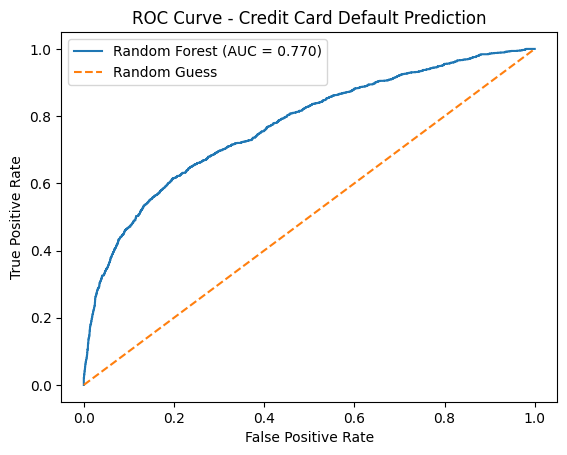

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
plt.figure()
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Card Default Prediction")
plt.legend()
plt.show()


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf_base = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist,
    n_iter=25,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train, y_train)


Fitting 5 folds for each of 25 candidates, totalling 125 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    n_jobs=-1,
                                                    random_state=42),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 3, 5],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [25]:
print("Best AUC (Randomized):", random_search.best_score_)
print("Best Params:", random_search.best_params_)


Best AUC (Randomized): 0.7807839244004999
Best Params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 30}


In [35]:
best_rf = random_search.best_estimator_
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]


Threshold seçimi


In [38]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_t = (y_proba_rf >= t).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred_t, average="binary"
    )
    results.append((t, precision, recall, f1))

for r in results:
    print(f"Threshold={r[0]:.2f} | Precision={r[1]:.3f} | Recall={r[2]:.3f} | F1={r[3]:.3f}")


Threshold=0.10 | Precision=0.240 | Recall=0.977 | F1=0.385
Threshold=0.15 | Precision=0.264 | Recall=0.940 | F1=0.413
Threshold=0.20 | Precision=0.298 | Recall=0.877 | F1=0.445
Threshold=0.25 | Precision=0.342 | Recall=0.792 | F1=0.478
Threshold=0.30 | Precision=0.391 | Recall=0.714 | F1=0.505
Threshold=0.35 | Precision=0.438 | Recall=0.643 | F1=0.521
Threshold=0.40 | Precision=0.480 | Recall=0.590 | F1=0.529
Threshold=0.45 | Precision=0.519 | Recall=0.547 | F1=0.532
Threshold=0.50 | Precision=0.544 | Recall=0.504 | F1=0.523
Threshold=0.55 | Precision=0.571 | Recall=0.472 | F1=0.517
Threshold=0.60 | Precision=0.605 | Recall=0.437 | F1=0.508
Threshold=0.65 | Precision=0.641 | Recall=0.383 | F1=0.479
Threshold=0.70 | Precision=0.672 | Recall=0.325 | F1=0.438
Threshold=0.75 | Precision=0.739 | Recall=0.258 | F1=0.382
Threshold=0.80 | Precision=0.761 | Recall=0.177 | F1=0.287
Threshold=0.85 | Precision=0.768 | Recall=0.103 | F1=0.181


In [39]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)
ap_score = average_precision_score(y_test, y_proba)

print("Average Precision:", ap_score)


Average Precision: 0.5509836466452569


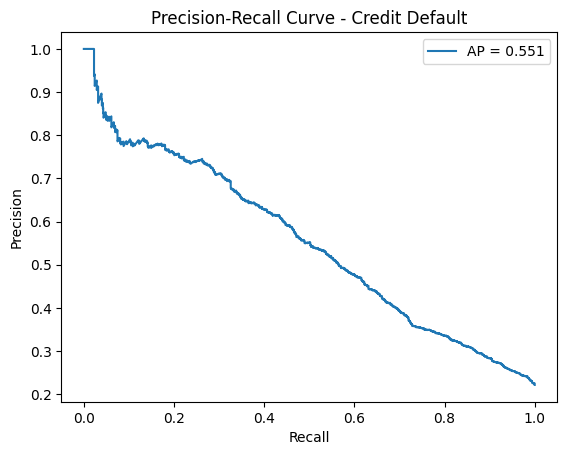

In [40]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(recall, precision, label=f"AP = {ap_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Credit Default")
plt.legend()
plt.show()


In [41]:
from sklearn.metrics import confusion_matrix
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)  # default threshold = 0.50

cm = confusion_matrix(y_test, y_pred)


# custom threshold=0.30
cm_new =confusion_matrix(y_test, (best_rf.predict_proba(X_test)[:,1] >= 0.30).astype(int))

print(cm)
print(cm_new)


[[4108  559]
 [ 658  668]]
[[3190 1477]
 [ 379  947]]


<Figure size 640x480 with 0 Axes>

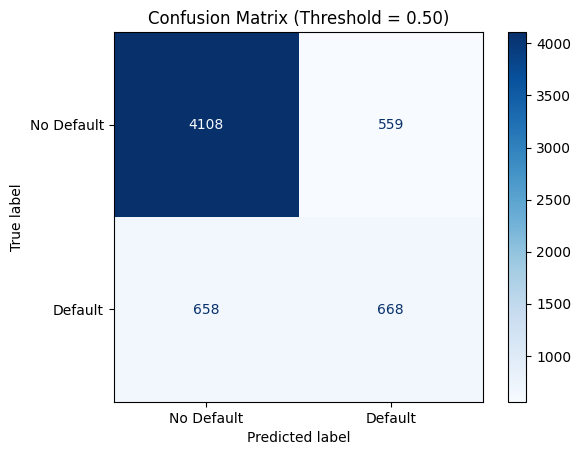

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure()
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Default", "Default"]
).plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix (Threshold = 0.50)")
plt.show()

<Figure size 640x480 with 0 Axes>

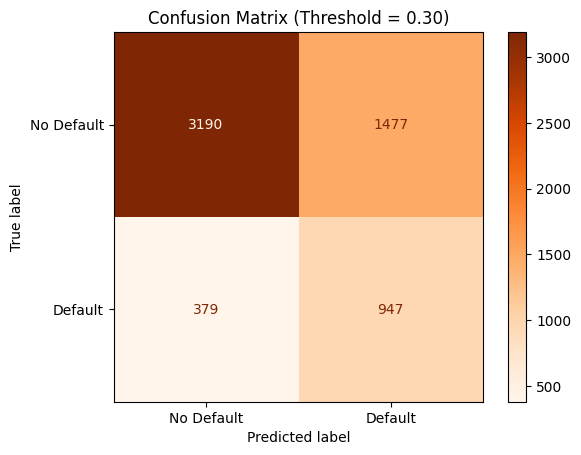

In [43]:
plt.figure()
ConfusionMatrixDisplay(
    confusion_matrix=cm_new,
    display_labels=["No Default", "Default"]
).plot(cmap="Oranges", values_format="d")

plt.title("Confusion Matrix (Threshold = 0.30)")
plt.show()

# Comparative Analysis and Interpretation

In this final section, we evaluate the performance of our trained models to select the most suitable candidate for credit card default prediction. Given the financial nature of the problem, our analysis focuses on minimizing risk.

**Strategy for Model Selection:**
* **Metric Prioritization:** Accuracy can be misleading due to class imbalance. We prioritize **F1-Score** and **Recall** (Sensitivity) because missing a defaulter (False Negative) carries a higher financial risk than a false alarm.
* **Visual Assessment:** We utilize ROC Curves to judge overall stability and Confusion Matrices to visualize the exact distribution of errors.

**Interpretation Goals:**
1.  **Identify the Champion Model:** We automatically select the model with the highest F1-Score for further analysis.
2.  **Error Analysis:** We inspect the probability distributions to understand the model's confidence levels and investigate the characteristics (e.g., Limit Balance) of misclassified customers.
3.  **Business Insight:** We interpret feature importance to understand which customer behaviors drive the model's decisions.

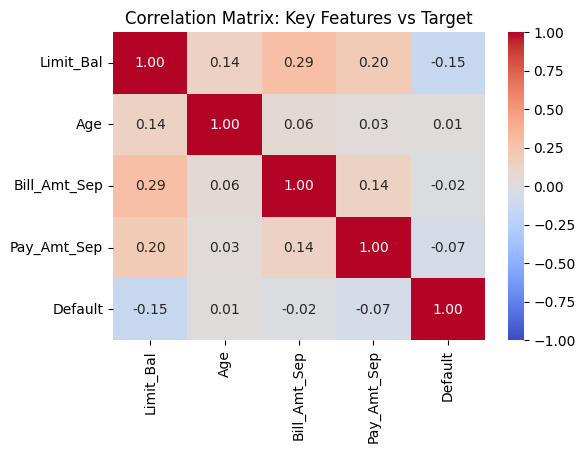

In [44]:
cols_to_analyze = ['Limit_Bal', 'Age', 'Bill_Amt_Sep', 'Pay_Amt_Sep', 'Default']
corr_matrix = df[cols_to_analyze].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix: Key Features vs Target")
plt.show()

**Limit_Bal vs Default (-0.15): En belirgin ilişki burada. Renk mavi (negatif).**

* Anlamı: Kredi limiti (Limit_Bal) arttıkça, batma riski (Default) azalıyor.

* Mantık: Banka zaten güvenmediği adama yüksek limit vermez. Yüksek limiti olanlar genelde finansal durumu daha iyi olanlardır.

**Pay_Amt_Sep vs Default (-0.07): Yine negatif (mavi) bir ilişki.**

* Anlamı: Eylül ayındaki ödeme miktarı (Pay_Amt_Sep) ne kadar yüksekse, kişinin batma ihtimali o kadar düşüktür. (Borcunu ödeyen batmaz).

**Age vs Default (0.01): Renk gri/beyaz (sıfıra yakın).**

* Anlamı: Yaş ile borç batırma arasında doğrusal bir ilişki yok. Gençler de batırabilir, yaşlılar da. Yaş tek başına bir gösterge değil.

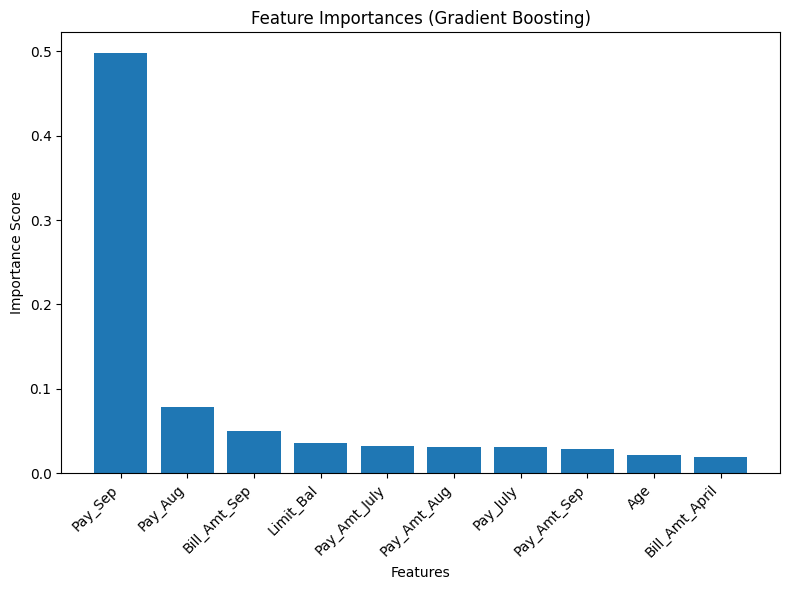

In [45]:
importances = best_gb_model.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 6))
plt.title("Feature Importances (Gradient Boosting)")
plt.bar(range(10), importances[indices[:10]], align="center")
plt.xticks(range(10), feature_names[indices[:10]], rotation=45, ha='right')
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

importance For Random Forest

In [46]:


importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(10))

Pay_Sep          0.146948
Bill_Amt_Sep     0.059842
Pay_Aug          0.057330
Pay_Amt_Sep      0.055484
Limit_Bal        0.053282
Pay_Amt_Aug      0.049902
Bill_Amt_Aug     0.048087
Pay_Amt_July     0.046150
Bill_Amt_July    0.044640
Pay_Amt_April    0.044408
dtype: float64


In [52]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Baseline (Dummy)": dummy_clf,
    "Logistic Regression": log_model,
    "Gradient Boosting (Tuned)": best_gb_model,
    "SVM (Balanced)": svm_model,
    "Random Forest": best_rf
}

model_evaluation_results = [] # Initialize an empty list to store results

for name, model in models.items():
    if name == "Random Forest":
        y_proba = model.predict_proba(X_test)[:, 1]   # pozitif sınıf olasılığı
        y_pred = (y_proba >= 0.3).astype(int) # Changed 0,3 to 0.3
    else:
      y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    model_evaluation_results.append({
          "Model": name,
          "Accuracy": acc,
          "Precision": prec,
          "Recall": rec,
          "F1 Score": f1
      })

results_df = pd.DataFrame(model_evaluation_results) # Create DataFrame from the list of dictionaries
results_df = results_df.sort_values(by="F1 Score", ascending=False)

# The best model selection should happen after the results_df is correctly populated
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
3,SVM (Balanced),0.766728,0.477041,0.564103,0.516932
4,Random Forest,0.690305,0.390677,0.714178,0.505067
2,Gradient Boosting (Tuned),0.815785,0.648000,0.366516,0.468208
1,Logistic Regression,0.813616,0.726681,0.252640,0.374930
0,Baseline (Dummy),0.778742,0.000000,0.000000,0.000000


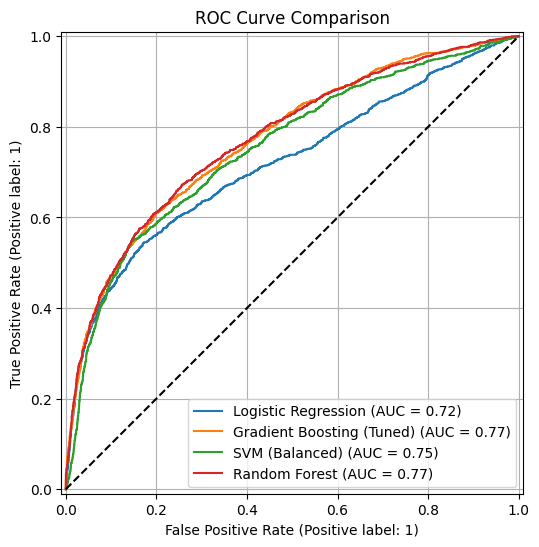

In [53]:
fig, ax = plt.subplots(figsize=(16, 6))

for name, model in models.items():
    # The dummy model might give an error or draw a straight line in the ROC drawing
    if "Dummy" not in name:
        RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], "k--", label="Chance Level (AUC = 0.5)")
ax.set_title("ROC Curve Comparison")
ax.grid(True)



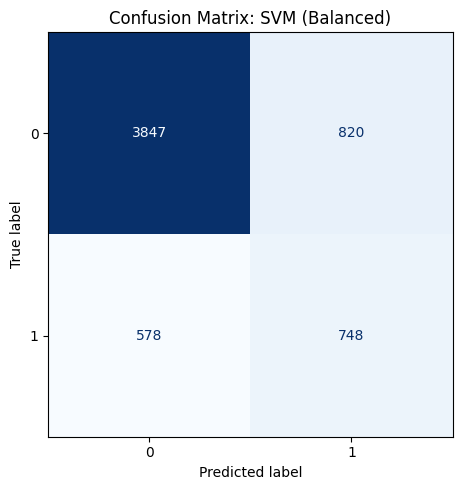

In [54]:
fig, ax1 = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap='Blues',
    colorbar=False,
    ax=ax1
)
ax1.set_title(f"Confusion Matrix: {best_model_name}")

plt.tight_layout()
plt.show()

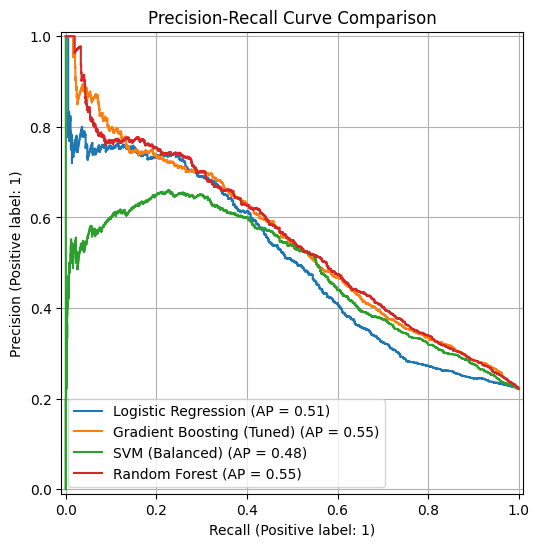

In [55]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(10, 6))

# all models
for name, model in models.items():
    if "Dummy" not in name: # Dummy models are generally not drawn on the PR curve or will be a straight line.
        display = PrecisionRecallDisplay.from_estimator(model, X_test, y_test, name=name, ax=plt.gca())

plt.title("Precision-Recall Curve Comparison")
plt.grid(True)
plt.show()

Count of Missed Defaults (FN): 578
Count of Correctly Identified Defaults (TP): 748


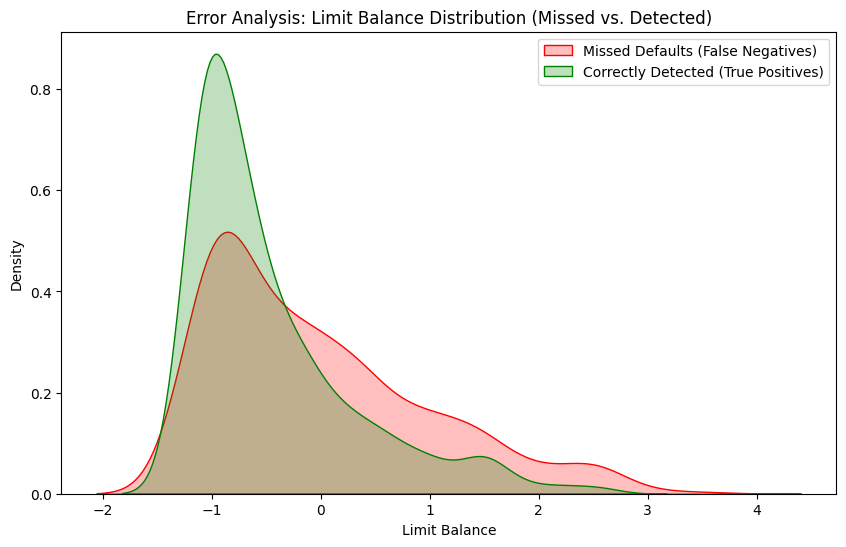

In [56]:
# Get the predictions (with best model)
y_pred = best_model.predict(X_test)

X_test_df = X_test.copy()
X_test_df['True_Label'] = y_test
X_test_df['Predicted_Label'] = y_pred

false_negatives = X_test_df[(X_test_df['True_Label'] == 1) & (X_test_df['Predicted_Label'] == 0)]
true_positives = X_test_df[(X_test_df['True_Label'] == 1) & (X_test_df['Predicted_Label'] == 1)]

print(f"Count of Missed Defaults (FN): {len(false_negatives)}")
print(f"Count of Correctly Identified Defaults (TP): {len(true_positives)}")


plt.figure(figsize=(10, 6))
sns.kdeplot(false_negatives['Limit_Bal'], label='Missed Defaults (False Negatives)', fill=True, color='red')
sns.kdeplot(true_positives['Limit_Bal'], label='Correctly Detected (True Positives)', fill=True, color='green')

plt.title("Error Analysis: Limit Balance Distribution (Missed vs. Detected)")
plt.xlabel("Limit Balance")
plt.ylabel("Density")
plt.legend()
plt.show()

In [ ]:
y_proba = best_gb_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(10, 6))

sns.histplot(y_proba[y_test == 0], color='blue', label='Actual: Non-Default (0)', alpha=0.5, bins=30)
sns.histplot(y_proba[y_test == 1], color='red', label='Actual: Default (1)', alpha=0.5, bins=30)

plt.axvline(0.5, color='black', linestyle='--', label='Threshold (0.5)')
plt.title("Prediction Probability Distribution")
plt.xlabel("Predicted Probability of Default")
plt.ylabel("Count")
plt.legend()
plt.show()

**Mavi Dağılım (Non-Default - Ödeyenler):**

* Görünüm: Grafiğin en solunda (0.1 - 0.2 arasında) çok yüksek bir tepe yapmış.

* Anlamı: Model, borcunu ödeyecek olanları çok büyük bir güvenle tanıyor. Onlara %10-%20 gibi düşük risk puanları vermiş. Bu harika bir şey.

**Kırmızı Dağılım (Default - Batanlar):**

* Görünüm: Yayvan ve düz bir dağılım var. Sağ tarafta (1.0'a yakın) keskin bir tepe yapamamış. Kırmızı çubuklar 0.3 ile 0.8 arasına yayılmış.

* Anlamı: Model, batacak olanları tespit etmekte zorlanıyor. Batacak kişilere "%90 batar" diyemiyor; genelde "%50-%60 ihtimalle batar" diyor.

* Risk: Kırmızıların bir kısmı 0.5 çizgisinin solunda kalmış (False Negative). Yani model bu kişilere "Riski %40, bence öder" demiş ama adamlar batmış.

**Çakışma Alanı (Overlap):**

* 0.3 ile 0.6 arasında Mavi ve Kırmızı çubuklar birbirine karışmış. Burası modelin kafasının karıştığı "Gri Bölge"dir.